# Mapper v5

## Librerías

In [10]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots



#### Funciones de docs en repositorio

from Funciones import calculate_metrics


## Recolección de datos

### Sacar tickers S&P500

In [11]:
START_DATE = "2024-10-08"
END_DATE = "2025-10-08"
AN_DATE = "2025-07-08"

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'GOOG', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['7.28%', '6.38%', '6.33%', '3.86%', '3.04%', '2.67%', '2.61%', '2.44%', '2.44%', '1.74%']
Tickers after replacement: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'GOOG', 'TSLA', 'BRK-B']


### Información financiera

In [12]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

print("🔍 Recopilando información detallada de todos los tickers del S&P 500...")
print("=" * 80)

ticker_info_db = {}
failed_tickers = []


for idx, ticker in enumerate(tickers, 1):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Extraer información relevante
        ticker_info_db[ticker] = {
            # Información básica
            'sector': info.get('sector', 'Unknown'),
            'industry': info.get('industry', 'Unknown'),
            'market_cap': info.get('marketCap', None),
            'country': info.get('country', 'Unknown'),
            'full_name': info.get('longName', ticker),
            
            # Métricas de valoración
            'pe_ratio': info.get('trailingPE', None),
            'forward_pe': info.get('forwardPE', None),
            'peg_ratio': info.get('pegRatio', None),
            'price_to_book': info.get('priceToBook', None),
            'price_to_sales': info.get('priceToSalesTrailing12Months', None),
            'enterprise_value': info.get('enterpriseValue', None),
            'ev_to_ebitda': info.get('enterpriseToEbitda', None),
            
            # Dividendos
            'dividend_yield': info.get('dividendYield', None),
            'dividend_rate': info.get('dividendRate', None),
            'payout_ratio': info.get('payoutRatio', None),
            'five_year_avg_dividend_yield': info.get('fiveYearAvgDividendYield', None),
            
            # Rentabilidad
            'profit_margins': info.get('profitMargins', None),
            'operating_margins': info.get('operatingMargins', None),
            'gross_margins': info.get('grossMargins', None),
            'roe': info.get('returnOnEquity', None),
            'roa': info.get('returnOnAssets', None),
            
            # Crecimiento
            'revenue_growth': info.get('revenueGrowth', None),
            'earnings_growth': info.get('earningsGrowth', None),
            'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
            
            # Riesgo y volatilidad
            'beta': info.get('beta', None),
            '52week_high': info.get('fiftyTwoWeekHigh', None),
            '52week_low': info.get('fiftyTwoWeekLow', None),
            '52week_change': info.get('52WeekChange', None),
            
            # Liquidez y deuda
            'current_ratio': info.get('currentRatio', None),
            'quick_ratio': info.get('quickRatio', None),
            'debt_to_equity': info.get('debtToEquity', None),
            'total_debt': info.get('totalDebt', None),
            'total_cash': info.get('totalCash', None),
            
            # Analistas y recomendaciones
            'recommendation': info.get('recommendationKey', 'Unknown'),
            'recommendation_mean': info.get('recommendationMean', None),
            'target_mean_price': info.get('targetMeanPrice', None),
            'target_high_price': info.get('targetHighPrice', None),
            'target_low_price': info.get('targetLowPrice', None),
            'number_of_analysts': info.get('numberOfAnalystOpinions', None),
            
            # Información adicional
            'employees': info.get('fullTimeEmployees', None),
            'exchange': info.get('exchange', 'Unknown'),
            'quote_type': info.get('quoteType', 'Unknown'),
        }
        
        
    except Exception as e:
        failed_tickers.append(ticker)
        ticker_info_db[ticker] = {
            'sector': 'Unknown',
            'industry': 'Unknown',
            'error': str(e)
        }

print(f"\n{'='*80}")
print(f"📊 RESUMEN DE RECOPILACIÓN:")
if failed_tickers:
    print(f"   Tickers fallidos: {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n DataFrame de información creado: {ticker_info_df.shape}")


# Guardar en CSV para uso posterior
ticker_info_df.to_csv('sp500_ticker_info_database.csv')
print("\n Base de datos guardada en 'sp500_ticker_info_database.csv'")

# Mostrar primeras filas
print("\n Primeras filas de la base de datos:")
display(ticker_info_df.head(10))

🔍 Recopilando información detallada de todos los tickers del S&P 500...

📊 RESUMEN DE RECOPILACIÓN:

 DataFrame de información creado: (503, 42)

 Base de datos guardada en 'sp500_ticker_info_database.csv'

 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,pe_ratio,forward_pe,peg_ratio,price_to_book,price_to_sales,...,total_cash,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price,number_of_analysts,employees,exchange,quote_type
NVDA,Technology,Semiconductors,4432980344832,United States,NVIDIA Corporation,51.725853,44.192963,None,44.268173,26.831099,...,5.679100e+10,strong_buy,1.34375,218.51369,320.0,100.0,57.0,36000.0,NMS,EQUITY
MSFT,Technology,Software - Infrastructure,3881706717184,United States,Microsoft Corporation,38.285920,34.931103,None,11.302485,13.778403,...,9.456500e+10,strong_buy,1.25862,621.26630,710.0,483.0,51.0,228000.0,NMS,EQUITY
AAPL,Technology,Consumer Electronics,3853900840960,United States,Apple Inc.,39.406677,31.250300,None,58.607536,9.431388,...,5.537200e+10,buy,2.04167,252.34805,315.0,175.0,41.0,150000.0,NMS,EQUITY
AMZN,Consumer Cyclical,Internet Retail,2348010438656,United States,"Amazon.com, Inc.",33.561310,35.798733,None,7.031465,3.504294,...,9.318000e+10,strong_buy,1.27941,266.56450,306.0,230.0,62.0,1546000.0,NMS,EQUITY
META,Communication Services,Internet Content & Information,1851549024256,United States,"Meta Platforms, Inc.",26.723717,29.132020,None,9.506270,10.355188,...,4.707100e+10,strong_buy,1.41176,866.85370,1086.0,616.0,62.0,75945.0,NMS,EQUITY
AVGO,Technology,Semiconductors,1626547814400,United States,Broadcom Inc.,88.090790,55.824146,None,5.816095,27.142607,...,1.110500e+10,strong_buy,1.28261,390.79630,460.0,273.4,41.0,37000.0,NMS,EQUITY
GOOGL,Communication Services,Internet Content & Information,3074540961792,United States,Alphabet Inc.,27.033012,28.330357,None,8.466131,8.276965,...,9.514800e+10,buy,1.52239,255.05260,340.0,185.0,54.0,187103.0,NMS,EQUITY
GOOG,Communication Services,Internet Content & Information,3075782475776,United States,Alphabet Inc.,27.192102,28.468157,None,8.497815,8.281612,...,9.514800e+10,buy,1.51471,249.86472,300.0,185.0,17.0,187103.0,NMS,EQUITY
TSLA,Consumer Cyclical,Auto Manufacturers,1485976764416,United States,"Tesla, Inc.",267.598820,137.929020,None,19.711098,16.036896,...,3.678200e+10,hold,2.55319,375.69280,600.0,120.0,39.0,125665.0,NMS,EQUITY
BRK-B,Financial Services,Insurance - Diversified,1057113571328,United States,Berkshire Hathaway Inc.,16.812070,24.414343,None,0.001056,2.855898,...,3.440910e+11,buy,2.00000,519.66670,593.0,479.0,3.0,392400.0,NYQ,EQUITY


### Datos históricos

In [13]:
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  503 of 503 completed

✅ Datos descargados:
   📊 Total: (250, 503) (desde 2024-10-08 hasta 2025-10-08)
   📊 Período de análisis: (186, 503) (desde 2024-10-08 hasta 2025-07-08)
   📊 Período de validación: (65, 503) (desde 2025-07-08 hasta 2025-10-08)


### Análisis inicial

In [14]:
# =======================================================
# 📈 ESTADÍSTICAS GENERALES DE LA BASE DE DATOS
# =======================================================

print("\n📈 ESTADÍSTICAS GENERALES DEL S&P 500:")
print("=" * 80)

# Distribución por Sector
print("\n🏢 DISTRIBUCIÓN POR SECTOR:")
sector_counts = ticker_info_df['sector'].value_counts()
for sector, count in sector_counts.items():
    pct = (count / len(ticker_info_df)) * 100
    print(f"   {sector:30s}: {count:3d} empresas ({pct:5.1f}%)")

# Top 10 Industrias
print("\n🏭 TOP 10 INDUSTRIAS:")
industry_counts = ticker_info_df['industry'].value_counts().head(10)
for industry, count in industry_counts.items():
    print(f"   {industry:50s}: {count:2d} empresas")

# Distribución por País
print("\n🌍 TOP 10 PAÍSES:")
country_counts = ticker_info_df['country'].value_counts().head(10)
for country, count in country_counts.items():
    pct = (count / len(ticker_info_df)) * 100
    print(f"   {country:30s}: {count:3d} empresas ({pct:5.1f}%)")

# Estadísticas de métricas financieras
print("\n💰 ESTADÍSTICAS DE MÉTRICAS FINANCIERAS (Medianas):")
financial_stats = {
    'Market Cap (Billones)': ticker_info_df['market_cap'].median() / 1e9 if ticker_info_df['market_cap'].notna().any() else None,
    'P/E Ratio': ticker_info_df['pe_ratio'].median(),
    'Beta': ticker_info_df['beta'].median(),
    'ROE (%)': ticker_info_df['roe'].median() * 100 if ticker_info_df['roe'].notna().any() else None,
    'Profit Margin (%)': ticker_info_df['profit_margins'].median() * 100 if ticker_info_df['profit_margins'].notna().any() else None,
    'Debt/Equity': ticker_info_df['debt_to_equity'].median(),
    'Dividend Yield (%)': ticker_info_df['dividend_yield'].median() * 100 if ticker_info_df['dividend_yield'].notna().any() else None,
}

for metric, value in financial_stats.items():
    if value is not None and not np.isnan(value):
        print(f"   {metric:25s}: {value:8.2f}")

# Empresas más grandes por Market Cap
print("\n🏆 TOP 10 EMPRESAS POR MARKET CAP:")
top_companies = ticker_info_df.nlargest(10, 'market_cap')[['full_name', 'sector', 'market_cap']]
for idx, (ticker, row) in enumerate(top_companies.iterrows(), 1):
    market_cap_b = row['market_cap'] / 1e9 if pd.notna(row['market_cap']) else 0
    print(f"   {idx:2d}. {ticker:5s} - {row['full_name'][:40]:40s} | ${market_cap_b:6.1f}B | {row['sector']}")

print(f"\n{'='*80}")
print("✅ Estadísticas generales completadas")


📈 ESTADÍSTICAS GENERALES DEL S&P 500:

🏢 DISTRIBUCIÓN POR SECTOR:
   Technology                    :  81 empresas ( 16.1%)
   Industrials                   :  72 empresas ( 14.3%)
   Financial Services            :  69 empresas ( 13.7%)
   Healthcare                    :  60 empresas ( 11.9%)
   Consumer Cyclical             :  55 empresas ( 10.9%)
   Consumer Defensive            :  37 empresas (  7.4%)
   Real Estate                   :  31 empresas (  6.2%)
   Utilities                     :  31 empresas (  6.2%)
   Communication Services        :  25 empresas (  5.0%)
   Energy                        :  22 empresas (  4.4%)
   Basic Materials               :  20 empresas (  4.0%)

🏭 TOP 10 INDUSTRIAS:
   Utilities - Regulated Electric                    : 23 empresas
   Software - Application                            : 17 empresas
   Specialty Industrial Machinery                    : 17 empresas
   Software - Infrastructure                         : 15 empresas
   Semiconductor

In [15]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T
ticker_names = metrics_df.index.tolist()


🔄 Calculando métricas financieras...


## Creación mapper

In [16]:
# =======================================================
# CREAR SUBCARPETA PARA VISUALIZACIONES
# =======================================================

import os

# Crear la subcarpeta para todas las visualizaciones
output_folder = 'portafolio_v5_visualizaciones'
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Subcarpeta creada: {output_folder}/")
print(f"🌐 Todas las visualizaciones HTML se guardarán en esta carpeta")

📁 Subcarpeta creada: portafolio_v5_visualizaciones/
🌐 Todas las visualizaciones HTML se guardarán en esta carpeta


### Configuración inicial mapper

In [17]:

# Escalamos
data = StandardScaler().fit_transform(tickers_data)

# Inicializamos Mapper
mapper = km.KeplerMapper(verbose=1)  # verbose=1 para ver debug info


KeplerMapper(verbose=1)


### Configuraciones varias

In [18]:

# Proyección (lens): PCA a 2D
lens = mapper.fit_transform(data, projection=PCA(n_components=2))

# Construcción del grafo con KMeans
graph_1 = mapper.map(
    lens, 
    data, 
    clusterer=KMeans(n_clusters=3, random_state=0),  # ✅ KMeans más confiable
    cover=km.Cover(n_cubes=10, perc_overlap=0.5)
)

print(f"✅ Nodos encontrados: {len(graph_1['nodes'])}")
print(f"✅ Aristas encontradas: {len(graph_1['links'])}")

# Visualización interactiva
mapper.visualize(graph_1, 
                 title="Mapper de series de tiempo",
                 custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                 path_html="portafolio_v5_visualizaciones/mapper_output.html")

..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (186, 503)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()

Mapping on data shaped (186, 503) using lens shaped (186, 2)

Creating 100 hypercubes.

Created 353 edges and 162 nodes in 0:00:00.189857.
✅ Nodos encontrados: 162
✅ Aristas encontradas: 128
Wrote visualization to: portafolio_v5_visualizaciones/mapper_output.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper de series de tiempo | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\

## Análisis resultados

### Extraer clusters

In [19]:
all_clusters = {}


# 1. Extraer clusters del grafo G (Sharpe Ratio)
print(f"\n Extrayendo clusters del análisis por Sharpe Ratio (G):")
print(f"Total de nodos: {len(graph_1['nodes'])}")
for i, (node_name, node_indices) in enumerate(graph_1['nodes'].items()):
    if len(node_indices) >= 4:  # Solo clusters con al menos 4 tickers
        cluster_tickers = [ticker_names[idx] for idx in node_indices]
        cluster_name = f"Config1_{i+1}"
        all_clusters[cluster_name] = {
            'tickers': cluster_tickers,
            'type': 'Sharpe Ratio',
            'node_name': node_name,
            'size': len(cluster_tickers)
        }
        print(f"     {cluster_name}: {cluster_tickers} ({len(cluster_tickers)} tickers)")


 Extrayendo clusters del análisis por Sharpe Ratio (G):
Total de nodos: 162
     Config1_4: ['DAY', 'DD', 'DDOG', 'DE', 'DECK'] (5 tickers)
     Config1_7: ['DAY', 'DD', 'DDOG', 'DE', 'DECK'] (5 tickers)
     Config1_10: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_14: ['DOW', 'DPZ', 'DRI', 'DTE'] (4 tickers)
     Config1_15: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_19: ['DAY', 'DD', 'DDOG', 'DE'] (4 tickers)
     Config1_22: ['CVS', 'DAY', 'DD', 'DDOG', 'DE'] (5 tickers)
     Config1_25: ['DHR', 'DIS', 'DLR', 'DLTR', 'DOC', 'DOV'] (6 tickers)
     Config1_29: ['DOW', 'DPZ', 'DRI', 'DTE'] (4 tickers)
     Config1_30: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_34: ['EL', 'ELV', 'EME', 'EMN', 'EMR', 'EOG'] (6 tickers)
     Config1_35: ['DUK', 'DVA', 'EFX', 'EG', 'EIX'] (5 tickers)
     Config1_37: ['EPAM', 'EQIX', 'EQR', 'EQT', 'ERIE', 'ETN'] (6 tickers)
     Config1_38: ['ETR', 'EVRG', 'EW', 'EXC', 'EXE', 'EXPD', 'EXR'] (7 tickers)
     Config1_39: [

In [20]:
categories = {ticker: ticker_info_db[ticker]['sector'] for ticker in ticker_names}
market_caps = {ticker: ticker_info_db[ticker]['market_cap'] for ticker in ticker_names}

### Crear portafolios

In [21]:
def create_market_cap_weighted_index(cluster_tickers, data, market_caps_dict, start_value=1):
    """
    Crea un índice ponderado por capitalización de mercado para un cluster específico.
    
    Parámetros:
    -----------
    cluster_tickers : list
        Lista de tickers del cluster
    data : pd.DataFrame
        DataFrame con precios históricos (tickers como columnas)
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    index_series : pd.Series
        Serie temporal del índice
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    # Filtrar tickers que existen tanto en data como en market_caps
    valid_tickers = [t for t in cluster_tickers if t in data.columns and t in market_caps_dict]
    
    if not valid_tickers:
        print(f"⚠️  No hay tickers válidos en el cluster")
        return None, None
    
    # Calcular capitalización total del cluster
    total_market_cap = sum([market_caps_dict[ticker] for ticker in valid_tickers])
    
    # Calcular pesos de cada ticker (capitalización / capitalización total)
    weights = {ticker: market_caps_dict[ticker] / total_market_cap for ticker in valid_tickers}
    
    # Crear el índice
    index_series = pd.Series(0, index=data.index)
    
    for ticker, weight in weights.items():
        # Normalizar precios del ticker al valor inicial
        ticker_prices = data[ticker].dropna()
        if len(ticker_prices) > 0:
            ticker_normalized = (ticker_prices / ticker_prices.iloc[0]) * start_value
            # Agregar al índice con su peso
            index_series = index_series.add(ticker_normalized * weight, fill_value=0)
    
    return index_series, weights

In [22]:
def create_all_cluster_indices(all_clusters, data, market_caps_dict, start_value=1):
    """
    Crea índices ponderados por capitalización para todos los clusters.
    
    Parámetros:
    -----------
    all_clusters : dict
        Diccionario con todos los clusters {cluster_name: {tickers: [...], ...}}
    data : pd.DataFrame
        DataFrame con precios históricos
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    cluster_indices : dict
        Diccionario con {cluster_name: {index: serie, weights: dict, metrics: dict}}
    """
    cluster_indices = {}
    
    
    
    for cluster_name, cluster_info in all_clusters.items():
        cluster_tickers = cluster_info['tickers']
        cluster_type = cluster_info['type']
        
        
        
        # Crear índice para este cluster
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, data, market_caps_dict, start_value
        )
        

    # Calcular métricas del índice
    returns = index_series.pct_change().dropna()

    total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1) * 1
    volatility = returns.std() * np.sqrt(252) * 1
    sharpe = (returns.mean() / returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
    max_drawdown = ((index_series / index_series.cummax()) - 1).min() * 1

    metrics = {
        'retorno_total': total_return,
        'volatilidad': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'valor_final': index_series.iloc[-1],
        'num_tickers': len(weights)
    }

    cluster_indices[cluster_name] = {
        'index': index_series,
        'weights': weights,
        'metrics': metrics,
        'type': cluster_type
    }



    # Mostrar los 3 tickers con mayor peso
    sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)


    
    
    
    return cluster_indices

In [23]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Sharpe Ratio', ascending=False)

print("\n📊 TOP 10 ÍNDICES POR SHARPE RATIO:")
print(summary_df.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   📈 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.2f}")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 88 clusters
   ✓ tickers_data: (186, 503)
   ✓ market_caps: 503 tickers con capitalización

  RESUMEN DE ÍNDICES CREADOS

📊 TOP 10 ÍNDICES POR SHARPE RATIO:
    Cluster         Tipo  Tickers  Retorno (%)  Volatilidad (%)  Sharpe Ratio  Max Drawdown (%)  Valor Final
Config1_159 Sharpe Ratio        5     0.132269         0.347085      0.658605         -0.301596     1.132269


📊 ESTADÍSTICAS GENERALES:
   📈 Retorno promedio: 0.13%
   📊 Volatilidad promedio: 0.35%
   ⭐ Sharpe Ratio promedio: 0.66
   📉 Max Drawdown promedio: -0.30%


In [24]:
validation_data

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-08,120.767494,209.771927,186.798340,136.990005,132.176300,90.209999,301.820465,382.239990,244.184265,54.086018,...,25.958220,110.207687,67.034988,113.137215,131.046539,67.839996,149.802811,93.241745,323.059998,157.274109
2025-07-09,121.056915,210.900650,187.635025,136.850006,132.037552,87.919998,295.919983,373.380005,241.763840,53.540695,...,25.938381,109.828560,67.312813,112.750816,131.186157,69.010002,150.121262,94.967522,321.779999,157.742538
2025-07-10,123.921158,212.169205,191.946442,137.000000,132.414169,88.559998,288.359985,371.429993,244.164352,54.423126,...,25.968140,111.674332,67.918076,113.870392,131.236008,68.760002,151.614014,94.917648,330.350006,158.270767
2025-07-11,123.032944,210.920624,189.436371,135.350006,130.848206,87.839996,281.059998,363.350006,243.716110,54.472698,...,26.097086,110.916069,68.086761,114.365784,130.587799,65.139999,149.066376,93.560966,327.140015,154.443573
2025-07-14,119.839355,208.383499,188.520935,138.570007,130.858109,90.589996,279.989990,366.989990,242.500931,53.838142,...,25.680485,110.756439,68.632484,112.869705,130.607758,68.680000,146.459030,93.630791,322.829987,155.131256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,138.580002,255.449997,242.630859,122.320000,132.879120,90.309998,243.710007,343.720001,239.279999,59.250000,...,24.950001,132.029999,80.309998,111.989998,147.880005,73.400002,153.190002,98.889999,291.790009,146.949997
2025-10-02,138.699997,257.130005,234.866821,121.489998,132.401245,89.080002,244.339996,351.480011,241.669998,59.110001,...,24.930000,133.339996,79.599998,111.290001,149.009995,76.809998,151.350006,99.169998,295.850006,146.490005
2025-10-03,141.639999,258.019989,232.235794,120.220001,133.994156,90.790001,245.320007,346.739990,241.990005,61.040001,...,25.120001,123.660004,80.260002,113.260002,149.850006,76.949997,150.690002,100.779999,305.010010,146.419998


🔍 Verificando datos necesarios...
   ✓ all_clusters: 88 clusters
   ✓ tickers_data: (186, 503)
   ✓ market_caps: 503 tickers con capitalización

  RESUMEN DE ÍNDICES CREADOS (PERÍODO DE VALIDACIÓN)

📊 TOP 10 ÍNDICES POR SHARPE RATIO:
    Cluster         Tipo  Tickers  Valor Inicial  Valor Final  Retorno (%)  Volatilidad (%)  Sharpe Ratio  Max Drawdown (%)
Config1_159 Sharpe Ratio        5            1.0     1.082819     0.082819         0.250914      1.374214         -0.074033


📊 ESTADÍSTICAS GENERALES:
   📈 Retorno promedio: 0.08%
   📊 Volatilidad promedio: 0.25%
   ⭐ Sharpe Ratio promedio: 1.37
   📉 Max Drawdown promedio: -0.07%


📈 Generando gráfica de los mejores 10 índices...


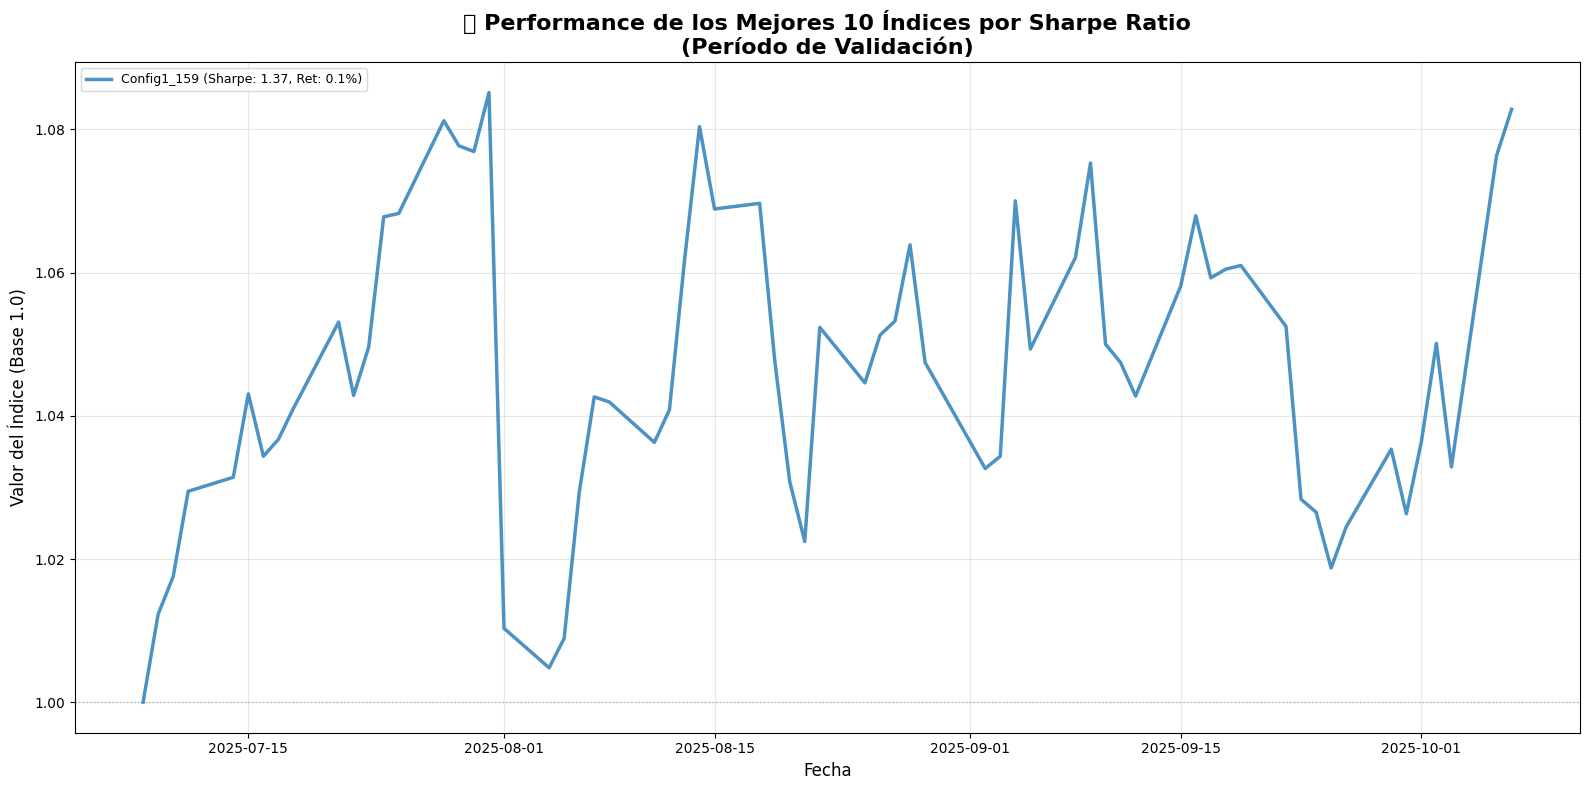


✅ Visualización completada


In [27]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=validation_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS (PERÍODO DE VALIDACIÓN)")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    index_series = cluster_data['index']
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Valor Inicial': index_series.iloc[0],  # ✅ Valor inicial
        'Valor Final': cluster_data['metrics']['valor_final'],  # ✅ Valor final
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Sharpe Ratio', ascending=False)

print("\n📊 TOP 10 ÍNDICES POR SHARPE RATIO:")
print(summary_df.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   📈 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.2f}")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")

# Paso 4: Visualizar los mejores 10 índices
print("\n\n📈 Generando gráfica de los mejores 10 índices...")

top_10_clusters = summary_df.head(10)['Cluster'].tolist()

# Crear figura con una sola gráfica
plt.figure(figsize=(16, 8))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i, cluster_name in enumerate(top_10_clusters):
    cluster_data = cluster_indices[cluster_name]
    index_series = cluster_data['index']
    sharpe = cluster_data['metrics']['sharpe_ratio']
    retorno = cluster_data['metrics']['retorno_total']
    
    plt.plot(index_series, 
            label=f"{cluster_name} (Sharpe: {sharpe:.2f}, Ret: {retorno:.1f}%)", 
            linewidth=2.5, alpha=0.8, color=colors[i])

# Agregar benchmark SPY si está disponible
if 'SPY' in validation_data.columns:
    spy_series = validation_data['SPY'].dropna()
    spy_normalized = spy_series / spy_series.iloc[0]
    plt.plot(spy_normalized, linewidth=3, linestyle='--', 
            color='black', alpha=0.7, label='SPY (Benchmark)')

plt.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.title('📊 Performance de los Mejores 10 Índices por Sharpe Ratio\n(Período de Validación)', 
         fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor del Índice (Base 1.0)', fontsize=12)
plt.legend(fontsize=9, loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Visualización completada")